# **Random Forest Regressor**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Garder seulement 3000 lignes aléatoires (sans override de df)
df_scaled = pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")
df_small = df_scaled.sample(n=3000, random_state=42)

print(df_small.shape)
df_small.head()

(3000, 29)


,Job_Title,Median_Salary_USD,Experience_Required_Years,Remote_Work_Ratio_%,Automation_Risk_%,Gender_Diversity_%,Job_Growth_Rate_%,Growth_Category,Job_Value_Index,Vulnerability_Index,...,Industry_retail,Industry_transportation,Location_australia,Location_brazil,Location_canada,Location_china,Location_germany,Location_india,Location_uk,Location_usa
2308,research scientist (life sciences),0.905473,-1.658495,0.596680,-0.678304,-1.156028,-0.216828,high_growth,1.134226,-0.684784,...,-0.375195,-0.372821,-0.380954,-0.376696,2.635720,-0.378713,-0.377446,-0.374732,-0.37992,-0.375830
22404,tefl teacher,0.837639,-0.173487,-0.094125,0.831030,0.465449,2.271770,high_growth,0.110340,0.639496,...,-0.375195,-0.372821,-0.380954,-0.376696,-0.379403,-0.378713,-0.377446,-0.374732,-0.37992,2.660774
23397,"editor, magazine features",0.167511,0.816517,-1.230967,-0.097176,-0.902473,-0.177612,high_growth,0.191606,0.706845,...,-0.375195,-0.372821,-0.380954,-0.376696,-0.379403,-0.378713,-0.377446,2.668572,-0.37992,-0.375830
25058,"journalist, magazine",1.443963,-0.338488,0.959517,0.490908,0.311464,-0.274272,decline,0.796400,-0.489038,...,-0.375195,-0.372821,-0.380954,-0.376696,-0.379403,2.640523,-0.377446,-0.374732,-0.37992,-0.375830
2664,"engineer, land",-1.116861,0.816517,-0.541197,1.029956,-1.409004,-0.119884,high_growth,-1.523452,1.247542,...,-0.375195,2.682253,2.624992,-0.376696,-0.379403,-0.378713,-0.377446,-0.374732,-0.37992,-0.375830


**Target Encoding function**

In [3]:
def target_encode(df, column, target):
    """Encode one categorical column using target mean."""
    mean_map = df.groupby(column)[target].mean()
    return df[column].map(mean_map)


**Préparation des données + Target Encoding**

In [4]:
target = "Automation_Risk_%"
X = df_small.drop(columns=[target])
y = df_small[target]

# Identify columns
num_cols = X.select_dtypes(include=["float64","int64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Num cols:", num_cols)
print("Cat cols:", cat_cols)

# Apply target encoding
X_encoded = X.copy()

for col in cat_cols:
    X_encoded[col] = target_encode(df_small, col, target)

# final df contains only numeric values
print("Final encoded shape:", X_encoded.shape)


Num cols: ['Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Gender_Diversity_%', 'Job_Growth_Rate_%', 'Job_Value_Index', 'Vulnerability_Index', 'Required_Education_num', 'AI_Impact_Level_num', 'Job_Status_num', 'Industry_education', 'Industry_entertainment', 'Industry_finance', 'Industry_healthcare', 'Industry_it', 'Industry_manufacturing', 'Industry_retail', 'Industry_transportation', 'Location_australia', 'Location_brazil', 'Location_canada', 'Location_china', 'Location_germany', 'Location_india', 'Location_uk', 'Location_usa']
Cat cols: ['Job_Title', 'Growth_Category']
Final encoded shape: (3000, 28)


**Train/Test split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


**Hyperparameter Grid for Random Forestt**

In [6]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters found:\n", grid_search.best_params_)


Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best parameters found:
 {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


**Train the best model**

In [7]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

print("Final Model Performance:")
print("MSE :", mean_squared_error(y_test, pred))
print("R²  :", r2_score(y_test, pred))


Final Model Performance:
MSE : 0.09650780601554354
R²  : 0.9095146031735714


**Feature Importances**

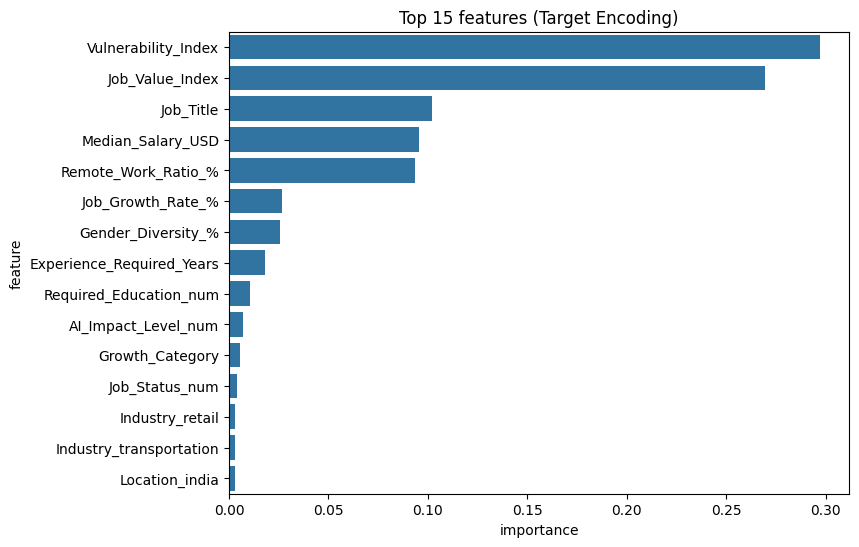

In [8]:
importances = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importances.head(15), x="importance", y="feature")
plt.title("Top 15 features (Target Encoding)")
plt.show()


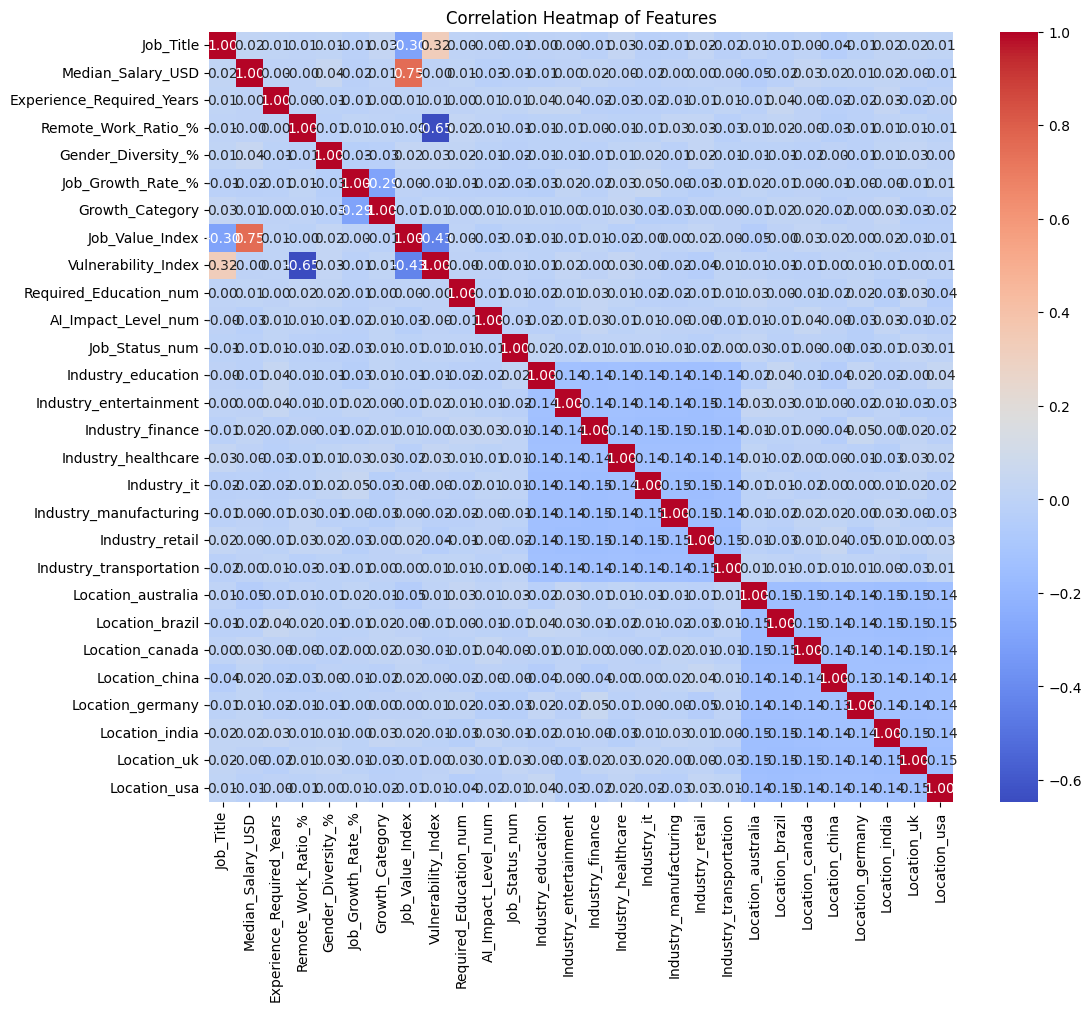

In [9]:
# Correlation matrix
corr_matrix = X_encoded.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Features")
plt.show()


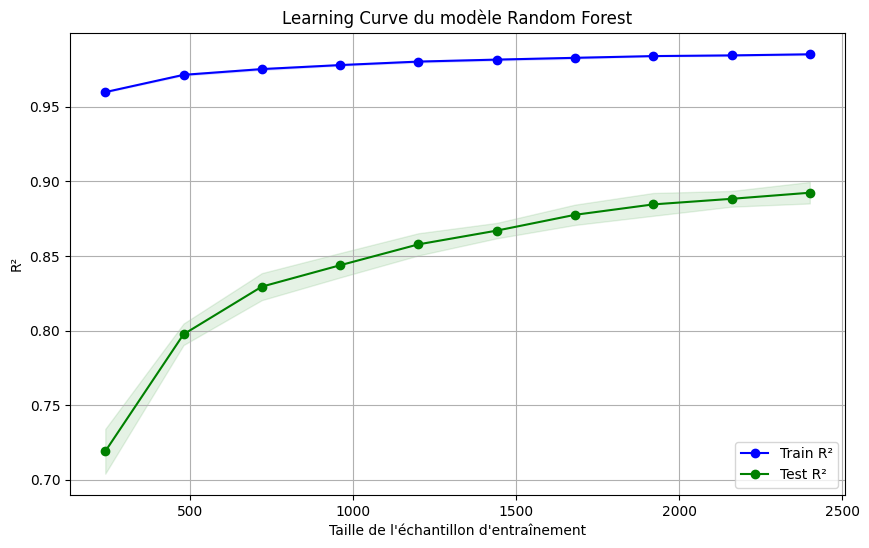

In [10]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_encoded, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Moyennes et écarts types
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Train R²")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Test R²")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="green")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("R²")
plt.title("Learning Curve du modèle Random Forest")
plt.legend()
plt.grid(True)
plt.show()


Top 20 métiers les plus à risque :
Job_Title
teacher, adult education                        1.687942
surveyor, minerals                              1.634037
production designer, theatre/television/film    1.503101
immunologist                                    1.385264
multimedia programmer                           1.348168
musician                                        1.334605
therapist, nutritional                          1.320520
exercise physiologist                           1.298089
land/geomatics surveyor                         1.295828
retail banker                                   1.293568
teacher, early years/pre                        1.264007
electronics engineer                            1.212623
jewellery designer                              1.174629
conservator, museum/gallery                     1.173064
adult guidance worker                           1.159675
merchant navy officer                           1.125246
corporate treasurer                        

C:\Users\amine gh\AppData\Local\Temp\ipykernel_20576\1723058439.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="Reds_r")


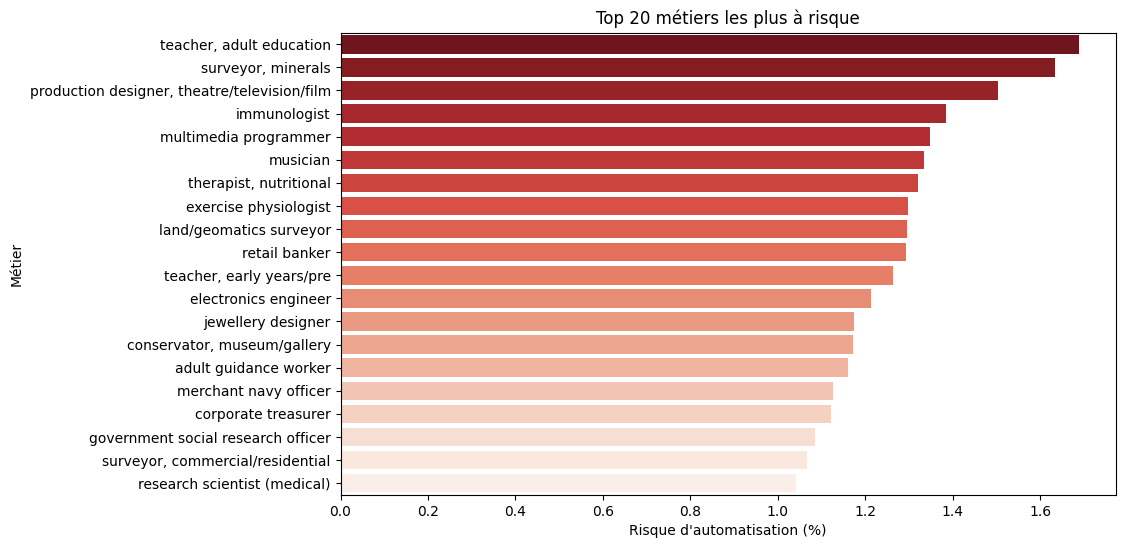

In [58]:
# Moyenne du risque par métier
top_jobs = df_small.groupby("Job_Title")["Automation_Risk_%"].mean().sort_values(ascending=False).head(20)

print("Top 20 métiers les plus à risque :")
print(top_jobs)

# Visualisation
plt.figure(figsize=(10,6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="Reds_r")
plt.xlabel("Risque d'automatisation (%)")
plt.ylabel("Métier")
plt.title("Top 20 métiers les plus à risque")
plt.show()
